# KAN vs MLP Comparasion

In [5]:
import numpy as np

SEED = 42
np.random.default_rng(seed=SEED)

Generator(PCG64) at 0x1ADEB778120

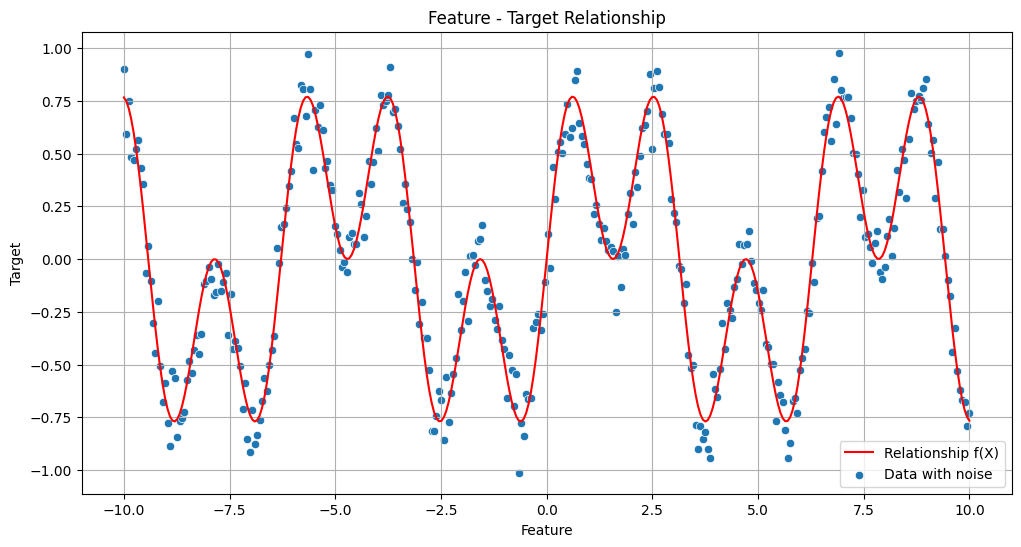

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

n = 350
range = (-10, 10)

X = np.linspace(range[0], range[1], n)
y_vis = np.sin(2*X)*np.cos(X)
y = y_vis + np.random.normal(0,0.1,X.shape)

plt.figure(figsize=(12,6))
plt.xlabel('Feature')
plt.ylabel('Target')
plt.grid()
plt.title('Feature - Target Relationship')
sns.lineplot(x=X,y=y_vis, color='red', label='Relationship f(X)')
sns.scatterplot(x=X, y=y, label='Data with noise')
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

split = 0.4

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split, random_state=SEED)

# Scale data using z-score standardization
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train.reshape(-1,1))
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()

X_test = X_scaler.transform(X_test.reshape(-1,1))
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()

# Check range coverage
print('Test data range: ', X_test.min(), X_test.max())
print('Train data range: ',X_train.min(), X_train.max())

Test data range:  -1.7315055285468346 1.7034649531857524
Train data range:  -1.7615490021479945 1.7335084267869119


In [8]:
from sklearn.metrics import mean_squared_error
from src.mlp import Network, ActivationLayer, FullyConnectedLayer
from src.utils import relu, relu_prime, mse, mse_prime
import optuna

n_trials = 50

# Network architecture definition

def make_mlp(layers):
    mlp = Network(mse, mse_prime, verbose=False)
    for layer in layers:
        mlp.add(layer)
    return mlp

layers = [
    FullyConnectedLayer(1, 128),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(128, 64),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(64, 32),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(32, 16),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(16, 1)
]

def objective(trial: optuna.Trial):
    mlp=make_mlp(layers)

    mlp.fit(
        X_train, y_train,
        epoches =       trial.suggest_int('epoches', 200, 700, step=10),
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        batch_size =    trial.suggest_categorical('batch_size', [16,32,64,128])
    )
    pred = mlp.predict(X_test)
    pred = np.array([x[0,0] for x in pred])
    return mean_squared_error(pred, y_test)

# study = optuna.create_study(study_name='MLP_opt',sampler=optuna.samplers.TPESampler(seed=SEED))
# study.optimize(objective, n_trials)

{'epoches': 700, 'learning_rate': 0.0015410483875564218, 'batch_size': 128}


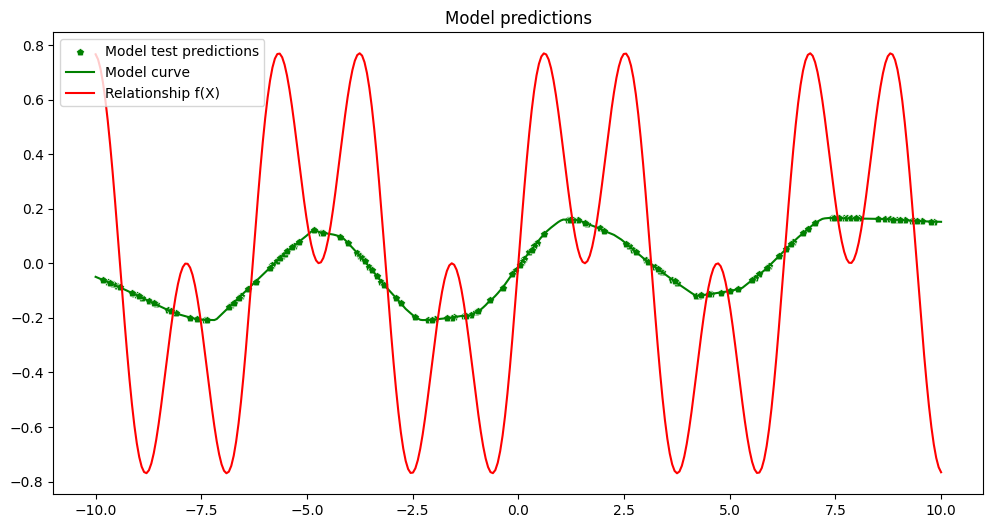

In [9]:
# Predict value and unwrap predictions to numpy array
print(study.best_params)
mlp=make_mlp(layers)
mlp.fit(X_train, y_train, **study.best_params)

vis = mlp.predict(X_scaler.transform(X.reshape(-1,1)).flatten())
pred = mlp.predict(X_test)
vis = np.array([x[0,0] for x in vis])
pred = np.array([x[0,0] for x in pred])

# Invert scaling
X_test_vis = X_scaler.inverse_transform(X_test).flatten()
vis = y_scaler.inverse_transform(vis.reshape(-1,1)).flatten()
pred = y_scaler.inverse_transform(pred.reshape(-1,1)).flatten()

# Plot
plt.figure(figsize=(12,6))
plt.title('Model predictions')
sns.scatterplot(x=X_test_vis, y=pred, color='green', marker='p', label='Model test predictions')
sns.lineplot(x=X, y=vis, color='green', label='Model curve')
sns.lineplot(x=X,y=y_vis, color='red', label='Relationship f(X)')
plt.show()

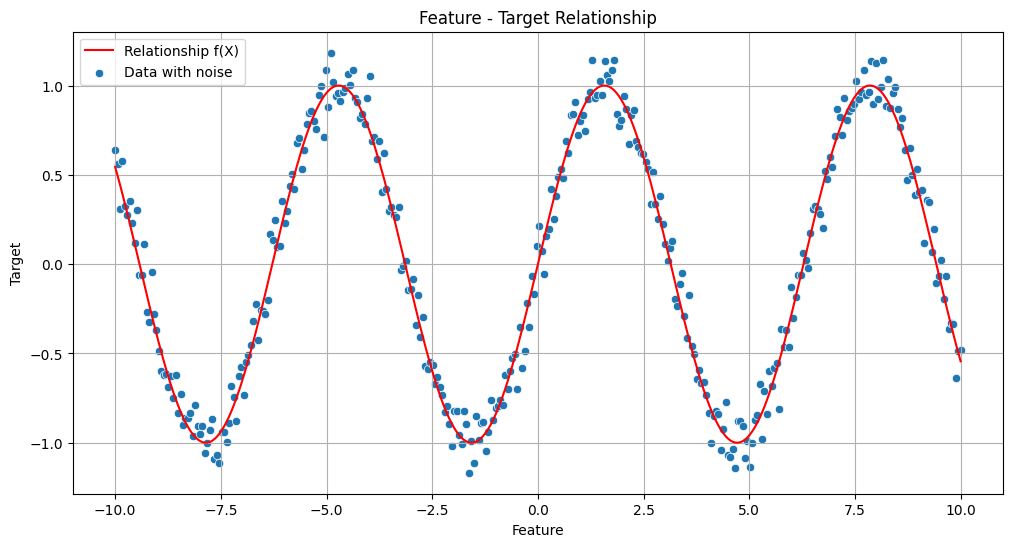

In [10]:
def simulate_data(f, n, range):
    X = np.linspace(range[0], range[1], n)
    
    y_vis = f(X)
    
    y = y_vis + np.random.normal(0,0.1,X.shape)

    plt.figure(figsize=(12,6))
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.grid()
    plt.title('Feature - Target Relationship')
    sns.lineplot(x=X,y=y_vis, color='red', label='Relationship f(X)')
    sns.scatterplot(x=X, y=y, label='Data with noise')
    plt.show()

simulate_data(
    lambda X: np.sin(X),
    n=350,
    range=(-10,10)
)

In [53]:
import pandas as pd

sim_data = pd.read_csv('./sim_data/sim_run_2025-11-10_19-10-18', index_col=0)

sim_data.head(5)

,genome,avg_train_loss,std_train_loss,max_train_loss,min_train_loss,avg_train_time,std_train_time,test_loss,inference_time
0,1,0.790768,0.024363,0.836863,0.752682,0.002642,0.003360,0.772989,0.001438
1,2,0.724010,0.014031,0.749741,0.701344,0.002282,0.000756,0.721502,0.000289
2,1_1,0.624017,0.000010,0.624061,0.624007,0.002573,0.000697,0.645845,0.000336
3,3,0.625224,0.004368,0.634774,0.619960,0.002119,0.000517,0.636683,0.000357
4,1_2,0.797620,0.031389,0.857165,0.748798,0.002520,0.000634,0.717420,0.000291


In [54]:
sim_data.iloc[sim_data.test_loss.argmin()]

genome               14_17
avg_train_loss    0.610272
std_train_loss    0.013663
max_train_loss    0.650323
min_train_loss    0.594801
avg_train_time    0.003581
std_train_time    0.000939
test_loss         0.581528
inference_time     0.00036
Name: 236, dtype: object

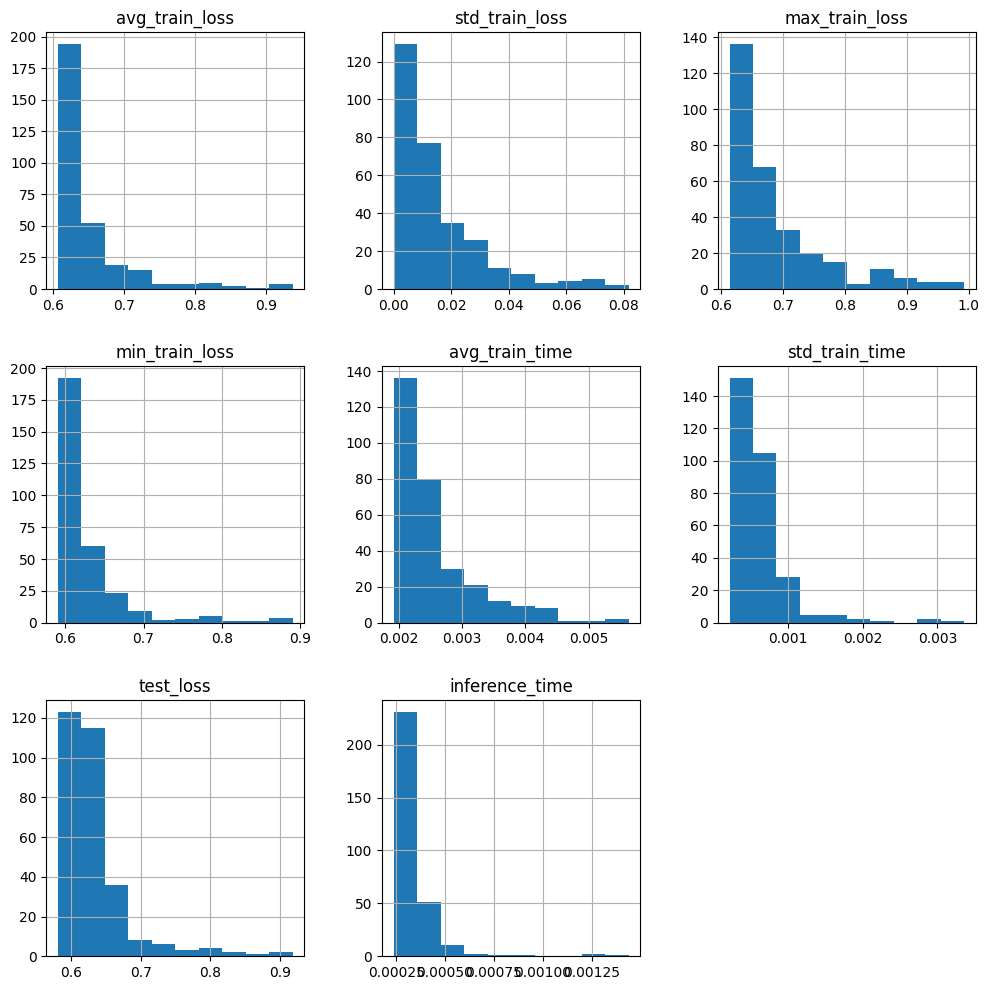

In [55]:
sim_data.hist(figsize=(12,12))
plt.show()

In [ ]:
sim_data['mlp_length'] = sim_data.genome.map(lambda x: len(x.split('_')))
sim_data['neuron_count'] = sim_data.genome.map(lambda x: sum(list(map(int, x.split('_')))))

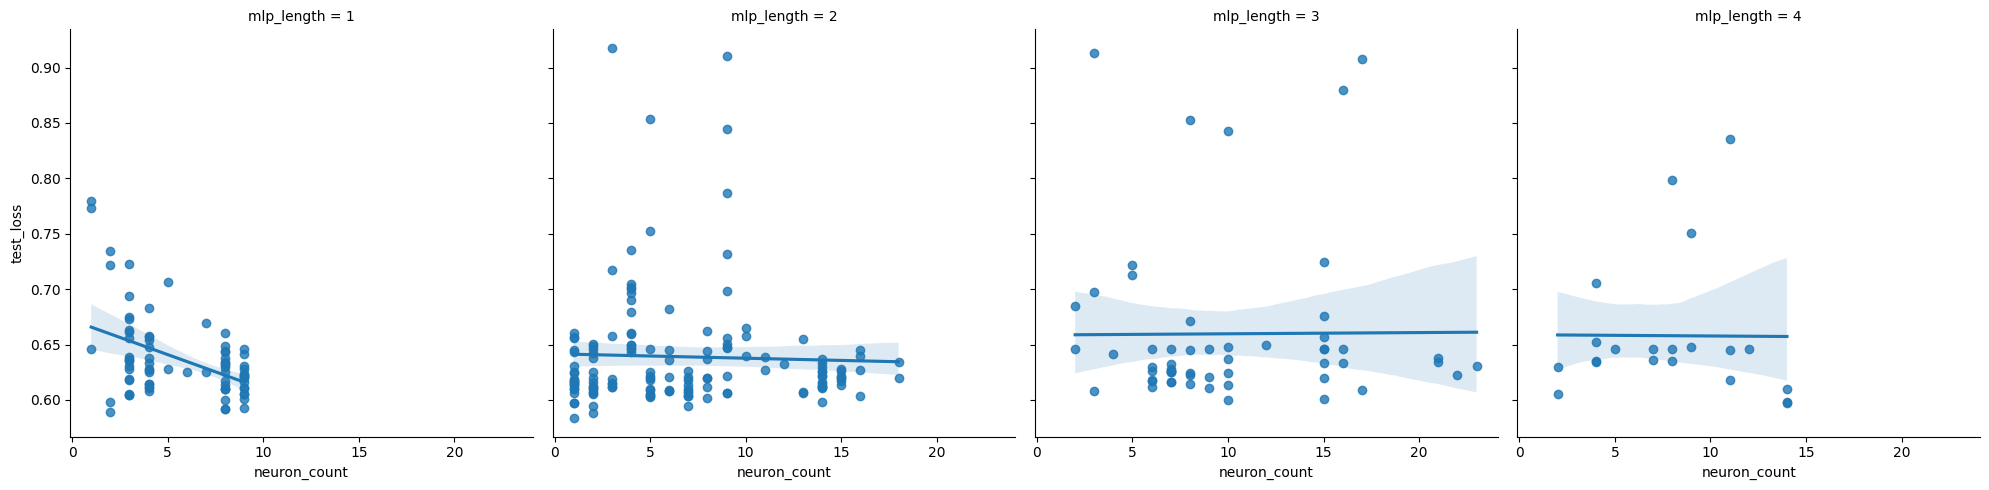

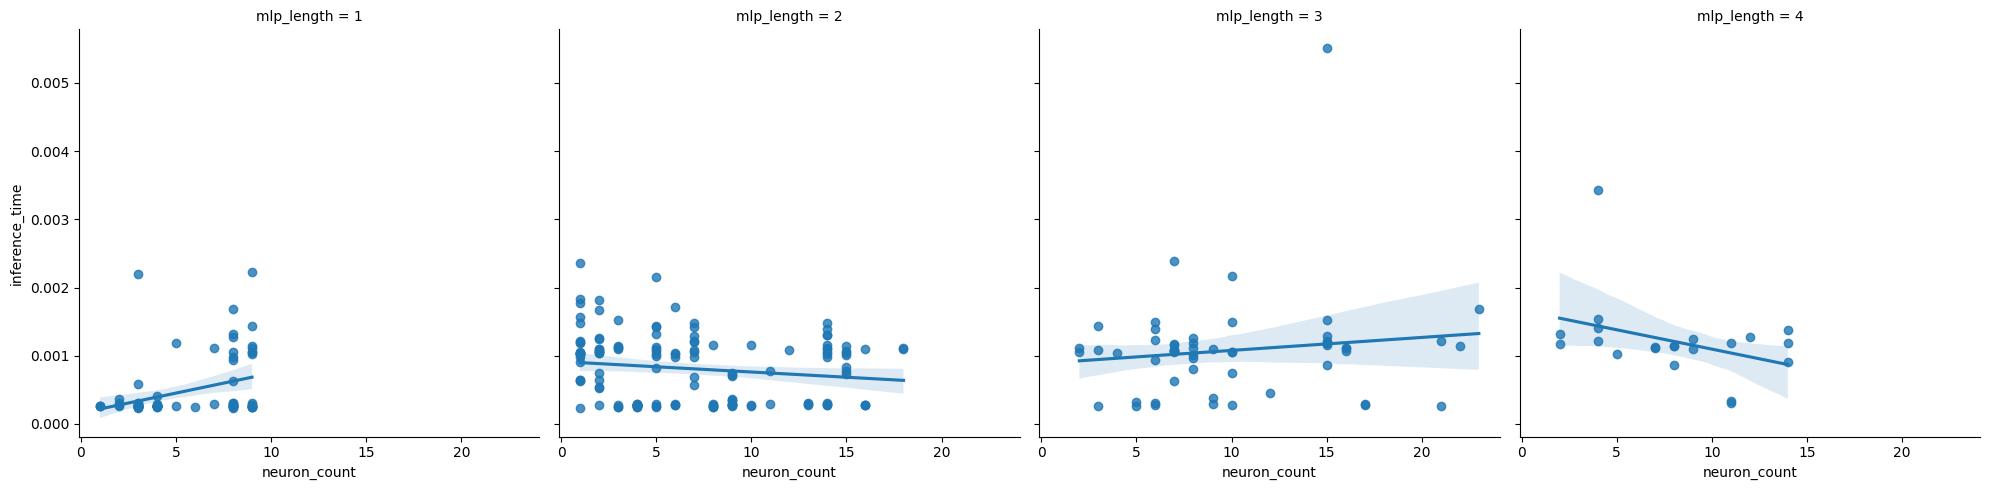

In [52]:
sns.lmplot(sim_data, x='neuron_count', y='test_loss', col='mlp_length')
sns.lmplot(sim_data, x='neuron_count', y='inference_time', col='mlp_length')